# Tutorial 12: Improving Autoencoder Reconstruction Quality

Improve upon basic autoencoders by implementing:
1.  **Deep Autoencoders**: Adding more dense layers to learn more complex hierarchical representations.
2.  **Convolutional Autoencoders (CAE)**: Using Convolutional layers (Conv2D, UpSampling2D) which are better suited for image data.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Conv2D, MaxPooling2D, UpSampling2D

# Load and preprocess MNIST dataset
(x_train, _), (x_test, _) = mnist.load_data()

# Normalize pixel values to [0, 1]
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


## 1. Deep Fully Connected Autoencoder
 More layers to the encoder and decoder to capture more complex features.

In [ ]:
# Reshape for Dense layers
x_train_flat = x_train.reshape((len(x_train), np.prod(x_train.shape[1:])))
x_test_flat = x_test.reshape((len(x_test), np.prod(x_test.shape[1:])))

input_img = Input(shape=(784,))
# Encoder
encoded = Dense(128, activation='relu')(input_img)
encoded = Dense(64, activation='relu')(encoded)
encoded = Dense(32, activation='relu')(encoded) # Latent space

# Decoder
decoded = Dense(64, activation='relu')(encoded)
decoded = Dense(128, activation='relu')(decoded)
decoded = Dense(784, activation='sigmoid')(decoded)

deep_autoencoder = Model(input_img, decoded)
deep_autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

deep_autoencoder.fit(x_train_flat, x_train_flat,
                epochs=20,
                batch_size=256,
                shuffle=True,
                validation_data=(x_test_flat, x_test_flat),
                verbose=0)
print("Deep Autoencoder trained.")

Deep Autoencoder trained.


## 2. Convolutional Autoencoder (CAE)
Convolutional layers preserve the spatial structure of the images, typically leading to much better reconstruction.

In [ ]:
# Reshape for Convolutional layers (Add channel dimension)
x_train_conv = np.reshape(x_train, (len(x_train), 28, 28, 1))
x_test_conv = np.reshape(x_test, (len(x_test), 28, 28, 1))

input_img_conv = Input(shape=(28, 28, 1))

# Encoder
x = Conv2D(16, (3, 3), activation='relu', padding='same')(input_img_conv)
x = MaxPooling2D((2, 2), padding='same')(x)
x = Conv2D(8, (3, 3), activation='relu', padding='same')(x)
encoded_conv = MaxPooling2D((2, 2), padding='same')(x)

# Decoder
x = Conv2D(8, (3, 3), activation='relu', padding='same')(encoded_conv)
x = UpSampling2D((2, 2))(x)
x = Conv2D(16, (3, 3), activation='relu', padding='same')(x)
x = UpSampling2D((2, 2))(x)
decoded_conv = Conv2D(1, (3, 3), activation='sigmoid', padding='same')(x)

cae = Model(input_img_conv, decoded_conv)
cae.compile(optimizer='adam', loss='binary_crossentropy')

cae.fit(x_train_conv, x_train_conv,
                epochs=20,
                batch_size=128,
                shuffle=True,
                validation_data=(x_test_conv, x_test_conv),
                verbose=0)
print("Convolutional Autoencoder trained.")

Convolutional Autoencoder trained.


## Visualizing Results
Compare the original images with the reconstructions from both models.

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step


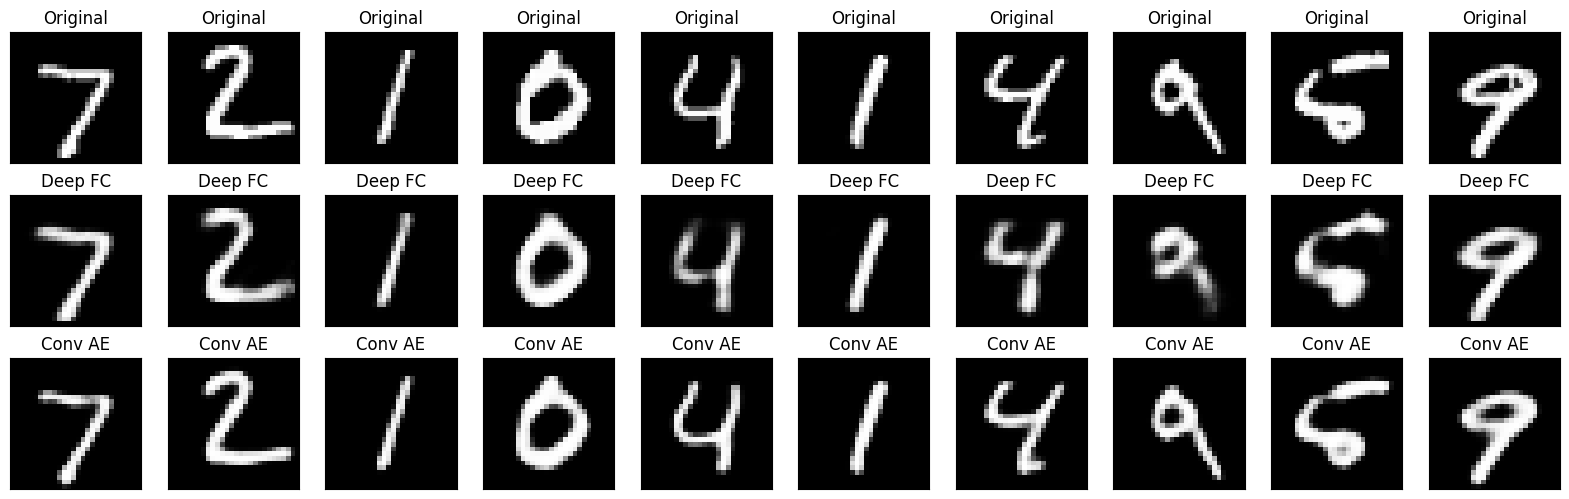

In [ ]:
decoded_deep = deep_autoencoder.predict(x_test_flat)
decoded_cae = cae.predict(x_test_conv)

n = 10
plt.figure(figsize=(20, 6))
for i in range(n):
    # Original
    ax = plt.subplot(3, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap='gray')
    plt.title("Original")
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    # Deep Autoencoder Reconstruction
    ax = plt.subplot(3, n, i + 1 + n)
    plt.imshow(decoded_deep[i].reshape(28, 28), cmap='gray')
    plt.title("Deep FC")
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    # CAE Reconstruction
    ax = plt.subplot(3, n, i + 1 + 2*n)
    plt.imshow(decoded_cae[i].reshape(28, 28), cmap='gray')
    plt.title("Conv AE")
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
plt.show()